In [11]:
# !unzip pedestrians.zip -d train
# !unzip "Test images-pedestrians.zip" -d test/
import scipy
import numpy as np
import matplotlib.pyplot as plt
import cv2
from sklearn import svm
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

# HOG

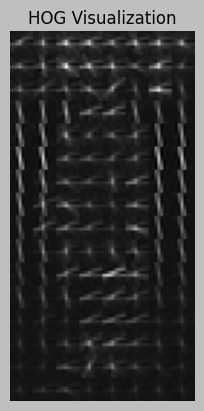

Rozmiar wektora HOG: (3780,)
Pierwsze 10 wartości: [0.17530975 0.0743807  0.12311163 0.04705418 0.07098294 0.05320389
 0.12493055 0.24065139 0.33817317 0.16498405]


In [12]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os
from scipy.ndimage import convolve1d, rotate
import math

class HOGDescriptor:
    def __init__(self, cell_size=8, num_bins=9):
        self.cell_size = cell_size
        self.num_bins = num_bins

    def calculate_gradient(self, img):
        if len(img.shape) == 2:
            dx = convolve1d(np.int32(img), np.array([-1, 0, 1]), axis=1)
            dy = convolve1d(np.int32(img), np.array([-1, 0, 1]), axis=0)
            magnitude = np.sqrt(dx ** 2 + dy ** 2)
            orientation = np.rad2deg(np.arctan2(dy, dx)) % 180
        else:
            dx = np.zeros_like(img, dtype=np.float32)
            dy = np.zeros_like(img, dtype=np.float32)
            magnitude = np.zeros_like(img, dtype=np.float32)
            orientation = np.zeros_like(img, dtype=np.float32)

            for c in range(3):
                dx[:, :, c] = convolve1d(np.int32(img[:, :, c]), np.array([-1, 0, 1]), axis=1)
                dy[:, :, c] = convolve1d(np.int32(img[:, :, c]), np.array([-1, 0, 1]), axis=0)
                magnitude[:, :, c] = np.sqrt(dx[:, :, c] ** 2 + dy[:, :, c] ** 2)
                orientation[:, :, c] = np.rad2deg(np.arctan2(dy[:, :, c], dx[:, :, c])) % 180

            idx = np.argmax(magnitude, axis=2)
            final_magnitude = np.zeros((img.shape[0], img.shape[1]), dtype=np.float32)
            final_orientation = np.zeros((img.shape[0], img.shape[1]), dtype=np.float32)

            for i in range(3):
                mask = (idx == i)
                final_magnitude[mask] = magnitude[:, :, i][mask]
                final_orientation[mask] = orientation[:, :, i][mask]

            magnitude = final_magnitude
            orientation = final_orientation

        return magnitude, orientation

    def calculate_histogram(self, magnitude, orientation, size):
        YY, XX = size[:2]
        YY_cell = YY // self.cell_size
        XX_cell = XX // self.cell_size

        bin_size = 180 / self.num_bins
        histograms = np.zeros((YY_cell, XX_cell, self.num_bins))

        for y in range(YY_cell):
            for x in range(XX_cell):
                mag_cell = magnitude[y*self.cell_size:(y+1)*self.cell_size,
                                     x*self.cell_size:(x+1)*self.cell_size]
                ori_cell = orientation[y*self.cell_size:(y+1)*self.cell_size,
                                       x*self.cell_size:(x+1)*self.cell_size]

                for i in range(self.cell_size):
                    for j in range(self.cell_size):
                        mag = mag_cell[i, j]
                        angle = ori_cell[i, j] % 180
                        bin_idx = int(angle // bin_size)
                        bin_center = bin_idx * bin_size + bin_size / 2

                        if angle < bin_center:
                            right_bin = bin_idx
                            left_bin = (bin_idx - 1) % self.num_bins
                            dist_right = bin_center - angle
                            dist_left = bin_size - dist_right
                        else:
                            left_bin = bin_idx
                            right_bin = (bin_idx + 1) % self.num_bins
                            dist_left = angle - bin_center
                            dist_right = bin_size - dist_left

                        total = dist_left + dist_right
                        w_left = dist_right / total
                        w_right = dist_left / total

                        histograms[y, x, left_bin] += mag * w_left
                        histograms[y, x, right_bin] += mag * w_right

        return histograms

    def normalize_blocks(self, hist):
        YY_cell, XX_cell = hist.shape[:2]
        e = math.pow(1e-5, 2)
        F = []

        for jj in range(YY_cell - 1):
            for ii in range(XX_cell - 1):
                H0 = hist[jj, ii, :]
                H1 = hist[jj, ii + 1, :]
                H2 = hist[jj + 1, ii, :]
                H3 = hist[jj + 1, ii + 1, :]
                H = np.concatenate((H0, H1, H2, H3))
                n = np.linalg.norm(H)
                Hn = H / np.sqrt(n**2 + e)
                F = np.concatenate((F, Hn))

        return F

    def visualize_hog(self, hist):
        bs = self.cell_size
        bim1 = np.zeros((bs, bs))
        bim1[bs // 2 : bs // 2 + 1, :] = 1

        bim = np.zeros(bim1.shape + (self.num_bins,))
        for i in range(self.num_bins):
            bim[:, :, i] = rotate(bim1, -i * (180 / self.num_bins), reshape=False, mode='nearest') / 255.0

        Y, X, _ = hist.shape
        hist = np.maximum(hist, 0)
        im = np.zeros((bs * Y, bs * X))

        for i in range(Y):
            for j in range(X):
                for k in range(self.num_bins):
                    im[i*bs:(i+1)*bs, j*bs:(j+1)*bs] += bim[:, :, k] * hist[i, j, k]

        plt.figure()
        plt.imshow(im, cmap='gray')
        plt.title("HOG Visualization")
        plt.axis("off")
        plt.show()

    def extract(self, img):
        img = cv2.resize(img, (64, 128))
        magnitude, orientation = self.calculate_gradient(img)
        hist = self.calculate_histogram(magnitude, orientation, img.shape)
        hog_vector = self.normalize_blocks(hist)
        self.visualize_hog(hist)
        return hog_vector
    
    def get_max_grad_mag_angle(self, img):
        """Returns gradient magnitude and orientation."""
        img = cv2.resize(img, (64, 128))
        return self.calculate_gradient(img)

    def get_block_histogram(self, mag_ang, cellSize=None):
        """Generates cell histogram from given gradient magnitude and angle."""
        magnitude, orientation = mag_ang
        return self.calculate_histogram(magnitude, orientation, magnitude.shape)

    def HOGpicture(self, hist, bs):
        """Generates a visualization image of HOG histogram data."""
        return self.visualize_hog_return(hist, bs)

    def visualize_hog_return(self, hist, bs):
        """Returns HOG visualization instead of displaying."""
        bim1 = np.zeros((bs, bs))
        bim1[bs // 2 : bs // 2 + 1, :] = 1

        bim = np.zeros(bim1.shape + (self.num_bins,))
        for i in range(self.num_bins):
            bim[:, :, i] = rotate(bim1, -i * (180 / self.num_bins), reshape=False, mode='nearest') / 255.0

        Y, X, _ = hist.shape
        hist = np.maximum(hist, 0)
        im = np.zeros((bs * Y, bs * X))

        for i in range(Y):
            for j in range(X):
                for k in range(self.num_bins):
                    im[i*bs:(i+1)*bs, j*bs:(j+1)*bs] += bim[:, :, k] * hist[i, j, k]

        return im



POS_DIR = "train/pos/"
NEG_DIR = "train/neg/"
pos_img_list = os.listdir(POS_DIR)
neg_img_list = os.listdir(NEG_DIR)

pos_image = cv2.imread(os.path.join(POS_DIR, pos_img_list[59]))
hog = HOGDescriptor()
features = hog.extract(pos_image)

print("Rozmiar wektora HOG:", features.shape)
print("Pierwsze 10 wartości:", features[:10])

Wektor cech HOG: [0.34384487 0.15958057 0.10338961 0.13061819 0.13671542 0.09076603
 0.0969405  0.19526628 0.1938845  0.16014424]
Długość wektora: 3780


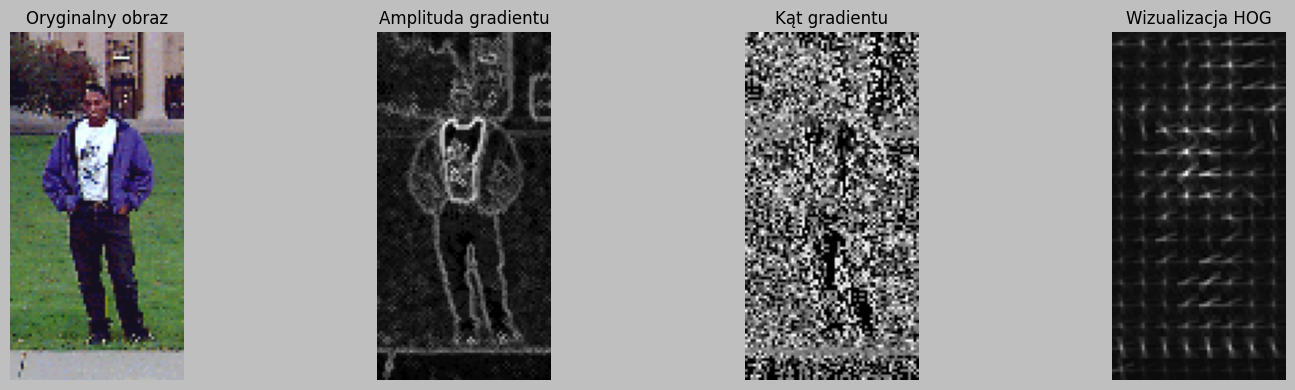

In [13]:
example_human = cv2.imread("train/pos/per00060.ppm")
hog = HOGDescriptor()
mag, ang = hog.get_max_grad_mag_angle(example_human)
hist = hog.get_block_histogram((mag, ang), cellSize=8)
descriptor = hog.normalize_blocks(hist)

print("Wektor cech HOG:", descriptor[:10])  # pierwsze 10 wartości
print("Długość wektora:", len(descriptor))  # powinno być ~3780 dla 64x128


plt.style.use('grayscale')
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(cv2.cvtColor(example_human, cv2.COLOR_BGR2RGB))
axes[0].set_title("Oryginalny obraz")
axes[1].imshow(mag, cmap='gray')
axes[1].set_title("Amplituda gradientu")
axes[2].imshow(ang, cmap='gray')
axes[2].set_title("Kąt gradientu")
axes[3].imshow(hog.HOGpicture(hist, 8), cmap='gray')
axes[3].set_title("Wizualizacja HOG")
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

# SVM

In [14]:
class HOG_SVM_Classifier:
    def __init__(self, hog_obj, pos_path='train/pos', neg_path='train/neg', 
                 pos_prefix='per', neg_prefix='neg', pos_ext='.ppm', neg_ext='.png',
                 n_samples=200, cell_size=8):
        self.hog = hog_obj
        self.pos_path = pos_path
        self.neg_path = neg_path
        self.pos_prefix = pos_prefix
        self.neg_prefix = neg_prefix
        self.pos_ext = pos_ext
        self.neg_ext = neg_ext
        self.n_samples = n_samples
        self.cell_size = cell_size
        self.clf = svm.SVC(kernel='linear', C=1.0)
        self.HOG_data = None
        self.labels = None
        self.data = None

    def compute_descriptor(self, image):
        # Zakładamy, że obraz ma rozmiar 64x128 lub go skalujemy
        if image.shape[0] != 128 or image.shape[1] != 64:
            image = cv2.resize(image, (64,128))
        # Używamy Twojej klasy HOG:
        magnitude, angle = self.hog.get_max_grad_mag_angle(image)
        hist = self.hog.get_block_histogram((magnitude, angle))
        descriptor = self.hog.normalize_blocks(hist)
        return descriptor

    def extract_hog_features(self):
        print("Extracting HOG features...")
        HOG_data = np.zeros([2 * self.n_samples, 3781], dtype=np.float32)  # 3780 + 1 label
        for i in range(self.n_samples):
            # Pozytywne
            pos_file = f'{self.pos_path}/{self.pos_prefix}{i+1:05d}{self.pos_ext}'
            IP = cv2.imread(pos_file)
            mag, ang = self.hog.get_max_grad_mag_angle(IP)
            hist = self.hog.get_block_histogram((mag, ang), cellSize=self.cell_size)
            desc = self.hog.normalize_blocks(hist)
            HOG_data[i, 0] = 1
            HOG_data[i, 1:] = desc

            # Negatywne
            neg_file = f'{self.neg_path}/{self.neg_prefix}{i+1:05d}{self.neg_ext}'
            IN = cv2.imread(neg_file)
            mag, ang = self.hog.get_max_grad_mag_angle(IN)
            hist = self.hog.get_block_histogram((mag, ang), cellSize=self.cell_size)
            desc = self.hog.normalize_blocks(hist)
            HOG_data[i + self.n_samples, 0] = 0
            HOG_data[i + self.n_samples, 1:] = desc

        self.HOG_data = HOG_data
        self.labels = HOG_data[:, 0]
        self.data = HOG_data[:, 1:]

    def train(self):
        if self.data is None or self.labels is None:
            raise ValueError("No data. Run extract_hog_features() first.")
        print("Training SVM classifier...")
        self.clf.fit(self.data, self.labels)

    def evaluate(self):
        print("Evaluating on training data...")
        preds = self.clf.predict(self.data)
        cm = confusion_matrix(self.labels, preds)
        TP = cm[1, 1]
        TN = cm[0, 0]
        FP = cm[0, 1]
        FN = cm[1, 0]
        accuracy = (TP + TN) / np.sum(cm)
        print("Confusion Matrix:\n", cm)
        print(f"TP: {TP}, TN: {TN}, FP: {FP}, FN: {FN}")
        print(f"Training accuracy: {accuracy * 100:.2f}%")
        return cm, accuracy

    def validate(self, test_size=0.2, random_state=42):
        print(f"Splitting data with test size = {test_size}")
        X_train, X_test, y_train, y_test = train_test_split(
            self.data, self.labels, test_size=test_size, random_state=random_state)
        print("Training on training split...")
        self.clf.fit(X_train, y_train)
        print("Predicting on test split...")
        y_pred = self.clf.predict(X_test)
        cm = confusion_matrix(y_test, y_pred)
        TP = cm[1, 1]
        TN = cm[0, 0]
        FP = cm[0, 1]
        FN = cm[1, 0]
        accuracy = (TP + TN) / np.sum(cm)
        print("Confusion Matrix (validation):\n", cm)
        print(f"TP: {TP}, TN: {TN}, FP: {FP}, FN: {FN}")
        print(f"Validation accuracy: {accuracy * 100:.2f}%")
        return cm, accuracy
    

hog = HOGDescriptor()
classifier = HOG_SVM_Classifier(hog, n_samples=900)
classifier.extract_hog_features()
classifier.train()               
classifier.evaluate()            
classifier.validate()            

Extracting HOG features...
Training SVM classifier...
Evaluating on training data...
Confusion Matrix:
 [[900   0]
 [  0 900]]
TP: 900, TN: 900, FP: 0, FN: 0
Training accuracy: 100.00%
Splitting data with test size = 0.2
Training on training split...
Predicting on test split...
Confusion Matrix (validation):
 [[178   0]
 [  1 181]]
TP: 181, TN: 178, FP: 0, FN: 1
Validation accuracy: 99.72%


(array([[178,   0],
        [  1, 181]]),
 np.float64(0.9972222222222222))

In [15]:
def non_max_suppression_fast(boxes, overlapThresh):
    if len(boxes) == 0:
        return []

    boxes = np.array(boxes)
    pick = []

    x1 = boxes[:,0]
    y1 = boxes[:,1]
    x2 = boxes[:,0] + boxes[:,2]
    y2 = boxes[:,1] + boxes[:,3]

    area = boxes[:,2] * boxes[:,3]
    idxs = np.argsort(y2)

    while len(idxs) > 0:
        last = idxs[-1]
        pick.append(last)
        idxs = idxs[:-1]

        xx1 = np.maximum(x1[last], x1[idxs])
        yy1 = np.maximum(y1[last], y1[idxs])
        xx2 = np.minimum(x2[last], x2[idxs])
        yy2 = np.minimum(y2[last], y2[idxs])

        w = np.maximum(0, xx2 - xx1)
        h = np.maximum(0, yy2 - yy1)

        overlap = (w * h) / area[idxs]

        idxs = idxs[overlap <= overlapThresh]

    return boxes[pick].astype(int)


# Human detection

In [16]:
class HumanDetector:
    def __init__(self, hog_svm_classifier, window_size=(64, 128), step_size=8, scale_factor=1.2):
        """
        Initialize the human detector with HOG-SVM classifier.
        
        Args:
            hog_svm_classifier: Trained HOG-SVM classifier
            window_size: Detection window size (width, height)
            step_size: Step size for sliding window (pixels)
            scale_factor: Scale factor for multiscale detection
        """
        self.classifier = hog_svm_classifier
        self.window_size = window_size
        self.step_size = step_size
        self.scale_factor = scale_factor

    def detect_multiscale(self, image, visualize=False, nms_thresh=0.3, multiscale=True):
        """
        Detect humans in an image using sliding window approach.
        
        Args:
            image: Input image (BGR format)
            visualize: Whether to draw detections on the image
            nms_thresh: Threshold for Non-Maximum Suppression
            multiscale: Whether to use multiscale detection
            
        Returns:
            final_boxes: List of detected bounding boxes [x, y, w, h]
            output_image: Image with detections drawn (if visualize=True)
        """
        detections = []
        output_img = image.copy()
        orig_h, orig_w = image.shape[:2]
        
        if not multiscale:
            # Single scale detection (original image size)
            scale = 1.0
            self._detect_at_scale(image, scale, detections)
        else:
            # Multiscale detection
            scale = 1.0
            while True:
                # Calculate new dimensions
                new_w = int(orig_w / scale)
                new_h = int(orig_h / scale)
                
                # Stop if image becomes smaller than window size
                if new_h <= self.window_size[1] or new_w <= self.window_size[0]:
                    break
                
                # Detect at current scale
                resized = cv2.resize(image, (new_w, new_h))
                self._detect_at_scale(resized, scale, detections)
                
                # Update scale for next iteration
                scale *= self.scale_factor

        # Apply Non-Maximum Suppression
        final_boxes = non_max_suppression_fast(detections, nms_thresh)

        if visualize:
            for (x, y, w, h) in final_boxes:
                cv2.rectangle(output_img, (x, y), (x + w, y + h), (0, 255, 0), 2)

        return final_boxes, output_img

    def _detect_at_scale(self, image, scale, detections):
        """
        Helper method to perform detection at a single scale.
        
        Args:
            image: Image at current scale
            scale: Current scale factor
            detections: List to store detected boxes
        """
        h, w = image.shape[:2]
        win_w, win_h = self.window_size
        
        for y in range(0, h - win_h, self.step_size):
            for x in range(0, w - win_w, self.step_size):
                window = image[y:y + win_h, x:x + win_w]
                
                try:
                    descriptor = self.classifier.compute_descriptor(window)
                    pred = self.classifier.clf.predict(descriptor.reshape(1, -1))
                    
                    if pred == 1:
                        # Convert coordinates to original scale
                        rx = int(x * scale)
                        ry = int(y * scale)
                        rw = int(win_w * scale)
                        rh = int(win_h * scale)
                        detections.append([rx, ry, rw, rh])
                except Exception as e:
                    # Skip windows that cause errors (e.g., too small after resize)
                    continue

libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: cHRM chunk does not match sRGB


[0.]


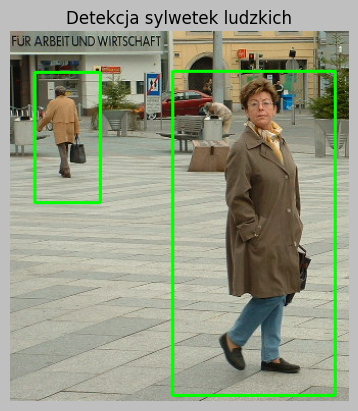

In [22]:
# image = cv2.imread("train/pos/per00004.ppm")
image = cv2.imread("test/testImage4.png")

descriptor = classifier.compute_descriptor(image)
print(classifier.clf.predict(descriptor.reshape(1, -1)))

detector = HumanDetector(classifier, step_size=8, window_size=(64, 128), scale_factor=1.2)
detections, image_with_boxes = detector.detect_multiscale(image, visualize=True, multiscale=True)

plt.imshow(cv2.cvtColor(image_with_boxes, cv2.COLOR_BGR2RGB))
plt.title("Detekcja sylwetek ludzkich")
plt.axis('off')
plt.show()